# C2 evaluation

Reads the fold predictions written by `c2_train_attributes.py` / `c2_train_images.py`.
Nothing is retrained here.

The notebook answers two questions, in order, and the sections map onto them one to one.

**Aim 1 - is there correctness signal in counterfactuals?** Section 1 plots the AUROC of every
attribute config and every CNN variant on its own, on an absolute scale. The question is
whether these models rank C0's mistakes at all, and which inputs carry the signal, so the
configs are shown as themselves rather than as a difference from something else.

**Aim 2 - is it better than the baseline?** Section 2 takes the single best attribute config
and the single best CNN per disease and puts them against MSP, with lollipops for the AUROC
gap and risk-coverage curves for the deployment view.

**The baseline is MSP**, the maximum softmax probability of Hendrycks & Gimpel - `max(p, 1-p)`
straight off C0, with no model fitted on top. That is the established failure-detection
baseline, and it is the honest thing to beat: a config like `B1` is an MLP *trained* on the
C0 probability, which is the method, not the reference. It is drawn as a thin grey dashed
reference everywhere it appears, and it is never a series colour.

`B1.2` (binary entropy of the probability) is excluded. Entropy is a monotone transform of
`max(p, 1-p)`, so it ranks identically to MSP and scores the same AUROC to four decimals -
it *is* the baseline, drawn twice.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# K = number of counterfactual neighbours the attributes are pooled over.
# Aim 1 draws every K in K_VALUES as its own colour, because K is a knob of the
# method and its effect is part of "is there signal". Aim 2 collapses to the
# single CF below, so the baseline comparison is one number per disease.
CF       = 1
K_VALUES = [1, 5, 10]

RESULTS = os.environ.get("THESIS_RESULTS", "/work3/s251710/thesis_results")
C2      = os.path.join(RESULTS, "C2_final_results")
SOURCE, POLICY = "knn_correct_cf", "ignore"
DISEASES = ["effusion", "atelectasis", "cardiomegaly", "consolidation", "edema"]
CNN_KEYS = ["xi", "xi_sal", "cf", "cf_sal", "dual", "dual_sal", "dual_sal_scalars"]
# Same idea as CONFIG_GROUPS: fixed order, with a rule separating the models that see a
# single image from those that see the query/counterfactual pair.
CNN_GROUPS = [["xi", "xi_sal", "cf", "cf_sal"], ["dual", "dual_sal", "dual_sal_scalars"]]
# The image models that never see a counterfactual. Shaded in the CNN ladder, and the
# reason their K lines coincide: with no CF input there is nothing for K to vary.
CNN_NO_CF = ["xi", "xi_sal"]

# Canonical config order -- NOT sorted by performance, so a config sits in the same
# row in every panel and the eye can track it across diseases. B1.2 is excluded (see above).
CONFIG_GROUPS = [
    ["B1", "B2", "B3", "B4", "B5"],
    ["M1", "M2", "M3", "M4", "M5", "M6"],
    ["MCF1", "MCF2", "MCF3", "MCF4", "MCF5"],
]
CONFIG_ORDER = [c for g in CONFIG_GROUPS for c in g]

# Palette. Categorical slots validated (OKLab CVD dE, normal-vision floor, lightness
# band, chroma floor, contrast vs surface) under all-pairs.
BLUE, VERM, TEAL = "#0072B2", "#D55E00", "#009E73"
# One colour per K, in K_VALUES order. Same validated categorical slots.
K_COLOR = dict(zip(K_VALUES, [BLUE, VERM, TEAL]))
GREY  = "#BFBFBF"   # MSP reference line -- thin, light grey, dashed. Never a series colour.
INK, MUTED, HAIR = "#2D2D2D", "#2D2D2D", "#E8E8E8"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.titlesize": 10, "axes.labelsize": 9, "legend.fontsize": 8,
    "grid.color": HAIR, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "font.size": 9, "figure.dpi": 120,
})

## Loaders

In [3]:
def attr_dir(d, k=None):     return os.path.join(C2, d, SOURCE, f"cf_{k or CF}", "attributes")
def cnn_dir(d, key, k=None): return os.path.join(C2, d, SOURCE, f"cf_{k or CF}", "images", key)

def load_attributes(disease, k=None, n_folds=5):
    """Pooled out-of-fold attribute predictions for one K; `fold` kept so per-fold
    means stay available. Returns None if that K has not finished, so a partially
    run K sweep still renders."""
    parts = []
    for i in range(n_folds):
        p = os.path.join(attr_dir(disease, k), f"fold_{i}_predictions.csv")
        if not os.path.exists(p):
            return None
        f = pd.read_csv(p); f["fold"] = i
        parts.append(f)
    return pd.concat(parts, ignore_index=True)

def load_cnn(disease, k=None, n_folds=5):
    """Pooled OOF CNN predictions, one column per FINISHED model (fold_aucs.csv present),
    so the notebook works mid-run.

    Columns are renamed `cnn_<key>`: the `cf` model writes `cf_prob`, which collides with
    the attribute frame's own `cf_prob` (mean counterfactual C0 probability) on merge.
    """
    out = None
    for key in CNN_KEYS:
        if not os.path.exists(os.path.join(cnn_dir(disease, key, k), "fold_aucs.csv")):
            continue
        parts = []
        for i in range(n_folds):
            p = os.path.join(cnn_dir(disease, key, k), f"fold_{i}_predictions.csv")
            if not os.path.exists(p): break
            f = pd.read_csv(p); f["fold"] = i
            parts.append(f)
        else:
            df = (pd.concat(parts, ignore_index=True)
                    [["path","patient_id","correct","fold",f"{key}_prob"]]
                    .rename(columns={f"{key}_prob": f"cnn_{key}"}))
            out = df if out is None else out.merge(df[["path", f"cnn_{key}"]], on="path", how="outer")
    return out

def msp(df, disease):
    """Maximum softmax probability -- the untrained baseline. Nothing is fitted."""
    p = df[f"{disease}_prob"].values
    return np.maximum(p, 1.0 - p)

def config_cols(df, model="MLP"):
    """Config -> column, in CONFIG_ORDER. Configs absent from the file are skipped."""
    have = {c.split("_",1)[1].rsplit("_prob",1)[0]: c
            for c in df.columns if c.startswith(f"{model}_") and c.endswith("_prob")}
    return {c: have[c] for c in CONFIG_ORDER if c in have}

def c0_threshold(disease, policy=POLICY):
    p = os.path.join(RESULTS, "C0_final", f"multilabel_{policy}", disease, "threshold.txt")
    return float(open(p).read().strip())

def panel_note(df, disease, policy=POLICY):
    """Per-panel subtitle: sample count and C0's error profile.

    n is NOT comparable across diseases by accident -- uncertain (-1) CheXpert labels have
    no defined C0 correctness and are dropped, and each disease loses a different number of
    them, so every panel is a different-sized set.

    FP/FN split C0's errors by the class it predicted. Neither `pred` nor `true` is stored
    in the fold predictions, but both are recoverable: pred = prob >= threshold, and since
    `correct` is exactly (pred == true), a wrong row has true = 1 - pred. So an error with
    pred=1 is a false positive and an error with pred=0 is a false negative. Percentages are
    of all rows, so FP% + FN% = the C0 error rate.
    """
    corr = df["correct"].values.astype(int)
    pred = (df[f"{disease}_prob"].values >= c0_threshold(disease, policy)).astype(int)
    n = len(df)
    fp = ((pred == 1) & (corr == 0)).sum() / n
    fn = ((pred == 0) & (corr == 0)).sum() / n
    return f"n={n:,}  ·  C0 err {1 - corr.mean():.1%}  (FP {fp:.1%} / FN {fn:.1%})"

def titled(ax, disease, df):
    ax.set_title(disease, color=INK, pad=17)
    ax.text(0.5, 1.015, panel_note(df, disease), transform=ax.transAxes,
            ha="center", va="bottom", fontsize=6.5, color=MUTED)

def per_fold_auc(df, score_col_or_values):
    """Mean AUROC over the 5 folds -- the same statistic cv_summary.csv reports."""
    v = df[score_col_or_values] if isinstance(score_col_or_values, str) else pd.Series(
        score_col_or_values, index=df.index)
    return float(np.mean([roc_auc_score(g["correct"], v.loc[g.index])
                          for _, g in df.groupby("fold")]))

## Metrics

AUROC here is scored on the C2 score directly (higher = more confident C0 is right); it is
symmetric under flipping the positive class, so the number is the same either way. AURC and
the budget metric below are *not* symmetric, and are defined error-first.

In [4]:
def risk_coverage(correct, score, min_n=200):
    """Retain the most-confident-first prefix. risk(c) = C0 error rate among the retained.

    `min_n` trims the left tail: at coverage ~0 the risk is an average over a handful of
    samples and swings between 0 and 1, which is sampling noise, not signal. AURC below
    still integrates the full curve -- only the plot is trimmed.
    """
    order = np.argsort(-np.asarray(score, float))
    y = np.asarray(correct, int)[order]
    k = np.arange(1, len(y) + 1)
    cov, risk = k / len(y), np.cumsum(1 - y) / k
    return cov[min_n - 1:], risk[min_n - 1:]

def aurc(correct, score):
    return risk_coverage(correct, score, min_n=1)[1].mean()

def e_aurc(correct, score):
    """Excess AURC: AURC minus that of a perfect ranking. Removes the base error rate,
    which spans 19-40% across these diseases and would otherwise dominate any comparison."""
    return aurc(correct, score) - aurc(correct, np.asarray(correct, float))

def errors_caught(correct, score, budget=0.20):
    """Flag the `budget` least-confident share; return the share of C0's errors caught."""
    y = np.asarray(correct, int)
    flagged = np.argsort(np.asarray(score, float))[:int(round(budget * len(y)))]
    n_err = (y == 0).sum()
    return (y[flagged] == 0).sum() / n_err if n_err else np.nan

# Aim 1 - is there correctness signal in counterfactuals?

Nothing in this section is a comparison against the baseline; that is Aim 2. Here each config
is plotted at **its own AUROC**, so the reading is "how well does this set of inputs rank C0's
errors" rather than "how much does it add". The shape of the line across configs is the thing
this section is about: it says which inputs carry the signal, and in particular what the
counterfactual features (`MCF*`) buy over the query-only ones (`M*`).

**One line per K**, the number of counterfactual neighbours the attributes are pooled over. K
is a knob of the method, not a nuisance parameter, and its effect belongs to this question:
on effusion `MCF5` goes 0.775 -> 0.783 -> 0.784 as K goes 1 -> 5 -> 10, crossing MSP on the
way. Every K is scored on the same rows with the same folds and the same MSP, so the three
lines in a panel are directly comparable. A K that has not finished on a disease is simply
absent from that panel (edema currently has K=1 only).

MSP is drawn as a thin grey dashed horizontal line - a reference, not a series.

**Each panel gets its own y range**, computed from that panel's own configs. The differences
that matter are small, thousandths of AUROC between `M*` and `MCF*` and between one K and the
next, and one range wide enough for five diseases flattens them all into a flat line.
Comparing diseases is not the goal here; seeing whether the counterfactual features move the
needle within a disease is. The absolute level is stated in each panel title.

The y range is **windowed**: `B2` and `M1` sit 0.15-0.20 below everything else on every
disease and would crush the competitive band on their own. They are clipped at the panel
floor with their value printed, so "far below" is visible without setting the scale.

Configs run along x in the canonical `B* -> M* -> MCF*` order rather than by rank, so a config
sits at the same x in every panel; hairlines separate the three families.

In [5]:
def line_panel(ax, rows, series, groups, ylim, base=None, colors=None, shade=None):
    """One disease: AUROC against config, one line per K.

    Values below the windowed floor are CLIPPED to it and listed under the panel,
    not dropped: the line has to stay connected or the eye reads a gap as a missing
    config, but drawing the true value would undo the window. The clipped marker is
    hollow so it cannot be misread as a real position.
    """
    lo, hi  = ylim
    colors  = colors or K_COLOR
    x       = np.arange(len(rows))
    ax.set_ylim(lo, hi)

    # Shade the reference family rather than only ruling a line after it: a band says
    # "this region is different in kind" where a rule only says "something changes
    # here". `shade` is an explicit config list, not a group index -- in the CNN
    # ladder the models with no counterfactual input are a PREFIX of the first group,
    # not the whole of it, so shading group 0 would wrongly cover cf and cf_sal.
    # min/max of the matched indices, not a count, so the band still lands correctly
    # when a config is missing from this panel.
    if shade:
        idx = [i for i, c in enumerate(rows) if c in shade]
        if idx:
            ax.axvspan(min(idx) - 0.5, max(idx) + 0.5, color=INK, alpha=0.045,
                       lw=0, zorder=0)

    if base is not None:
        ax.axhline(base, color=GREY, ls="--", lw=1.0, zorder=2)

    seen = 0
    for g in groups[:-1]:
        seen += sum(1 for c in g if c in rows)
        if 0 < seen < len(rows):
            ax.axvline(seen - 0.5, color=HAIR, lw=0.8, zorder=0)

    # Clipped values are collected per config, not per K: the K series sit within a
    # few thousandths of each other down there, so three labels on one x would land
    # on top of each other.
    clipped = {}
    for k, vals in series.items():
        y    = np.array([vals.get(c, np.nan) for c in rows], float)
        clip = y < lo
        ax.plot(x, np.where(clip, lo, y), "-o", ms=3.2, lw=1.3,
                color=colors[k], zorder=3, label=f"K={k}")
        for xi, yi in zip(x[clip], y[clip]):
            ax.plot(xi, lo, "o", ms=5.5, mfc="white", mec=colors[k], mew=1.0, zorder=4)
            clipped.setdefault(int(xi), []).append(yi)

    # Clipped configs are listed in ONE note under the axes rather than labelled in
    # place. On effusion six configs fall below the floor and their in-place labels
    # land on top of each other and on the lines. Exact values are in the summary
    # table.
    if clipped:
        names = ", ".join(rows[i] for i in sorted(clipped))
        worst = min(v for vs in clipped.values() for v in vs)
        ax.text(0.0, -0.40, f"below axis: {names}  (min {worst:.3f})",
                transform=ax.transAxes, fontsize=5.5, color=MUTED, va="top", ha="left")

    # Rows are the GLOBAL config list, identical in every panel, so a config keeps its
    # x position across diseases. A config missing from one panel leaves a gap in the
    # line there rather than shifting everything left.
    ax.set_xticks(x); ax.set_xticklabels(rows, fontsize=7, rotation=90)
    ax.set_xlim(-0.5, len(rows) - 0.5)
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    # Square PLOTTING AREA. set_box_aspect fixes the axes box, where a square figsize
    # would only fix the cell and let the rotated labels and title squash the plot
    # inside it. Not set_aspect("equal"), which equalises data units -- x spans 16
    # config slots against y's ~0.05 AUROC, and that would collapse the panel.
    ax.set_box_aspect(1)
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
    return ax


def k_legend(ks):
    return ([Line2D([],[],color=K_COLOR[k],lw=1.3,marker="o",ms=3.2,label=f"K={k}") for k in ks]
            + [Line2D([],[],color=MUTED,lw=0,marker="o",ms=5.5,mfc="white",
                      label="clipped to axis floor (listed under panel)"),
               Line2D([],[],color=GREY,lw=1.0,ls="--",label="MSP baseline (reference)")])


def _grid(n, ncols, panel=(4.0, 4.6)):
    """Axes grid with the unused trailing cells removed.

    Cells are taller than wide even though the axes are square: the extra height is
    what the rotated x labels, the two title lines and the below-axis note consume,
    so the square plot sits in the cell without a wide margin.
    """
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel[0] * ncols, panel[1] * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.remove()
    return fig, axes[:n]


def auroc_ylim(series, base, win=0.05):
    """Y window for one panel: a fixed-height `win` band anchored at the top of the data.

    Anchored at the TOP, not fitted to the full range, because the configs that matter
    sit within a few thousandths of each other near the ceiling and a full-range axis
    flattens them into one line. Anything that falls out of the bottom is clipped and
    listed by `line_panel` rather than dropped.

    The MSP baseline is always inside the window -- it is the line every config is read
    against, so a panel that cropped it out would be unreadable. The window is widened
    to reach it rather than re-centred, which keeps `win` the floor on panel height and
    not the exact height.
    """
    vals = [v for d in series.values() for v in d.values() if np.isfinite(v)]
    if base is not None and np.isfinite(base):
        vals = vals + [base]
    if not vals:
        return (0.5, 0.5 + win)
    hi = max(vals)
    lo = min(hi - win, min(vals) if base is None else min(base, hi - win))
    # Breathing room so markers and the baseline never sit exactly on a spine.
    pad = 0.04 * (hi - lo)
    return (lo - pad, hi + pad)


def _panel_title(ax, disease, df, base=None):
    """Panel title: disease, then a small subtitle with n, C0's error profile and MSP.

    Same two-line form as `titled`, plus the MSP baseline value -- in the ladder figures
    the grey dashed line is the thing every config is judged against, so its number
    belongs on the panel rather than only in the legend.
    """
    ax.set_title(disease, color=INK, pad=17)
    note = panel_note(df, disease)
    if base is not None and np.isfinite(base):
        note += f"  \u00b7  MSP {base:.3f}"
    ax.text(0.5, 1.015, note, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=6.5, color=MUTED)


## 1a. Attribute configs

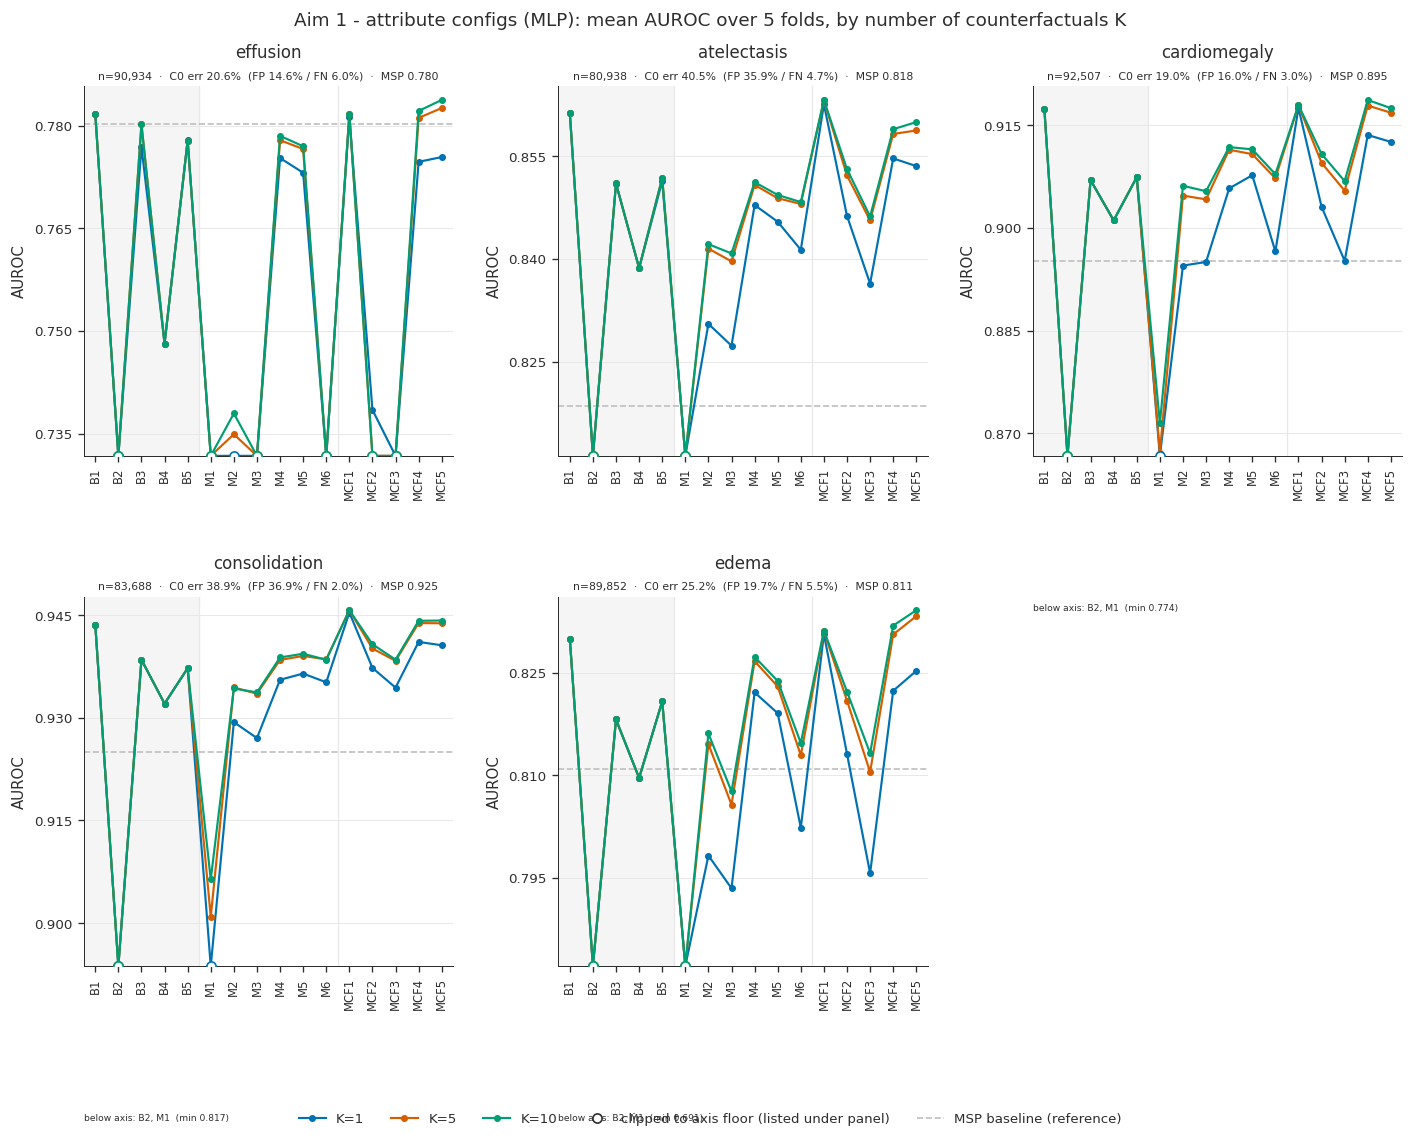

In [6]:
def config_ladder(diseases=DISEASES, model="MLP", ks=None, win=0.05,
                  ncols=3, panel=(4.0, 4.6)):
    """AUROC against config, one line per K, one panel per disease."""
    ks     = ks or K_VALUES
    panels = []
    for d in diseases:
        # {k: frame}; a K that has not finished on this disease is dropped, not faked.
        frames = {k: f for k in ks if (f := load_attributes(d, k)) is not None}
        if not frames:
            continue
        # MSP is K-independent -- same C0 probability on the same rows -- so it is
        # scored once on whichever K is present.
        ref  = frames[next(iter(frames))]
        base = per_fold_auc(ref, msp(ref, d))
        series = {k: {c: per_fold_auc(f, col) for c, col in config_cols(f, model).items()}
                  for k, f in frames.items()}
        panels.append((d, ref, base, series))

    if not panels:
        print("no attribute predictions yet"); return
    rows = [c for c in CONFIG_ORDER if any(c in s[k] for _, _, _, s in panels for k in s)]

    fig, axes = _grid(len(panels), ncols, panel)
    for ax, (d, ref, base, series) in zip(axes, panels):
        # Shade the B* family: it is the reference the rest of the ladder is read against.
        line_panel(ax, rows, series, CONFIG_GROUPS,
                   auroc_ylim(series, base, win), base=base, shade=CONFIG_GROUPS[0])
        _panel_title(ax, d, ref, base)
        ax.set_ylabel("AUROC")
    fig.legend(handles=k_legend(ks), loc="lower center", ncol=len(ks) + 2, frameon=False,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f"Aim 1 - attribute configs ({model}): mean AUROC over 5 folds, "
                 f"by number of counterfactuals K", y=1.0, fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0.02, 1, 0.99))
    return fig

config_ladder();


## 1b. Estimator comparison (LR vs RF vs MLP)

Same ladder, but instead of picking one estimator's columns per panel, average each
estimator's mean fold AUROC over the five diseases and put the three on one plot. This
is what justifies fitting the rest of the notebook's ladders and tables on MLP: it is
at or above the MSP baseline almost everywhere LR and RF are not, and the legend counts
how often each estimator wins a given disease/config cell outright, not just on average.

Fitted at K=1 (`CF`), not swept: the estimator ranking is stable across K, and three
estimators times three K on one panel is unreadable.


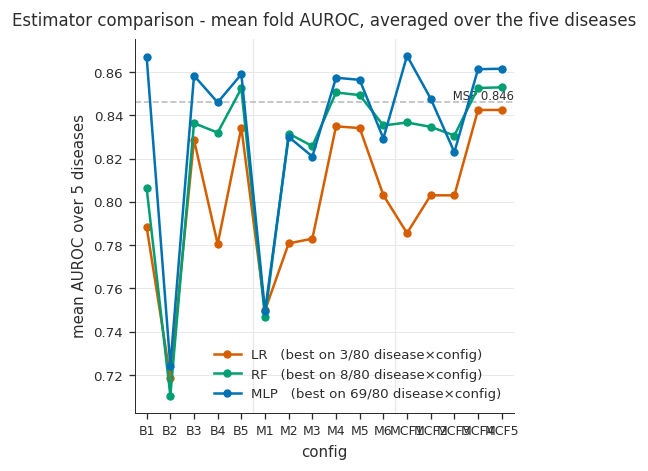

In [7]:
MODELS      = ["LR", "RF", "MLP"]
MODEL_COLOR = {"MLP": BLUE, "RF": TEAL, "LR": VERM}

def model_grid(diseases=DISEASES, models=MODELS):
    """(model, config) -> mean fold AUROC, averaged over the diseases.

    Every model is fitted on the same folds of the same rows, so the disease average is a
    like-for-like comparison; it is not comparable to any single panel of the ladder above,
    where the absolute level ranges from ~0.78 to ~0.93.
    """
    # Estimator choice is orthogonal to K, so this is fitted at the single CF
    # defined at the top rather than swept -- three estimators times three K on one
    # panel is unreadable, and the ranking does not change with K.
    frames = {d: f for d in diseases if (f := load_attributes(d, CF)) is not None}
    per_disease = {m: {d: {c: per_fold_auc(f, col)
                           for c, col in config_cols(f, m).items()}
                       for d, f in frames.items()} for m in models}
    grid = {m: {c: np.mean([v[c] for v in per_disease[m].values() if c in v])
                for c in CONFIG_ORDER
                if any(c in v for v in per_disease[m].values())} for m in models}
    base = float(np.mean([per_fold_auc(f, msp(f, d)) for d, f in frames.items()]))
    return grid, per_disease, base, frames


def model_comparison(diseases=DISEASES, models=MODELS, figsize=(4, 4)):
    """One line per estimator across the config ladder -- the figure that picks MLP.

    Averaging over diseases is what makes a single panel legible, so the per-disease
    win count is printed next to each legend entry: it is the claim the mean line is
    making, counted rather than eyeballed.
    """
    grid, per_disease, base, frames = model_grid(diseases, models)
    rows = [c for c in CONFIG_ORDER if any(c in grid[m] for m in models)]
    x    = np.arange(len(rows))

    # Cells = (disease, config) pairs; the winner is the estimator with the highest
    # mean fold AUROC on that cell. Ties are impossible at this precision.
    cells = [(d, c) for d in per_disease[models[0]] for c in rows]
    wins  = {m: sum(1 for d, c in cells
                    if max(models, key=lambda k: per_disease[k][d].get(c, -1)) == m)
             for m in models}

    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(base, color=GREY, ls="--", lw=1.0, zorder=1)
    ax.text(len(rows) - 0.5, base, f" MSP {base:.3f}", color=MUTED, fontsize=7,
            ha="right", va="bottom")

    seen = 0
    for g in CONFIG_GROUPS[:-1]:
        seen += sum(1 for c in g if c in rows)
        if 0 < seen < len(rows):
            ax.axvline(seen - 0.5, color=HAIR, lw=0.8, zorder=0)

    for m in models:
        y = [grid[m].get(c, np.nan) for c in rows]
        ax.plot(x, y, "-o", ms=4, lw=1.5, color=MODEL_COLOR[m], zorder=3,
                label=f"{m}   (best on {wins[m]}/{len(cells)} disease\u00d7config)")

    ax.set_xticks(x); ax.set_xticklabels(rows, fontsize=7.5)
    ax.set_xlim(-0.5, len(rows) - 0.5)
    ax.set_xlabel("config"); ax.set_ylabel("mean AUROC over 5 diseases")
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
    ax.legend(frameon=False, loc="lower right", ncol=1)
    ax.set_title("Estimator comparison - mean fold AUROC, averaged over the five diseases",
                 color=INK, pad=8)
    fig.tight_layout()
    return fig

model_comparison();

## 1c. CNN variants

The image models on the same absolute axis, read the same way: what does each set of image
inputs know about C0's correctness. The rule separates the models that see a single image
from those that see the query/counterfactual pair, which is the comparison this figure exists
to make.

Only models with a complete `fold_aucs.csv` appear, so this renders correctly mid-run;
diseases with no finished CNN are skipped entirely.

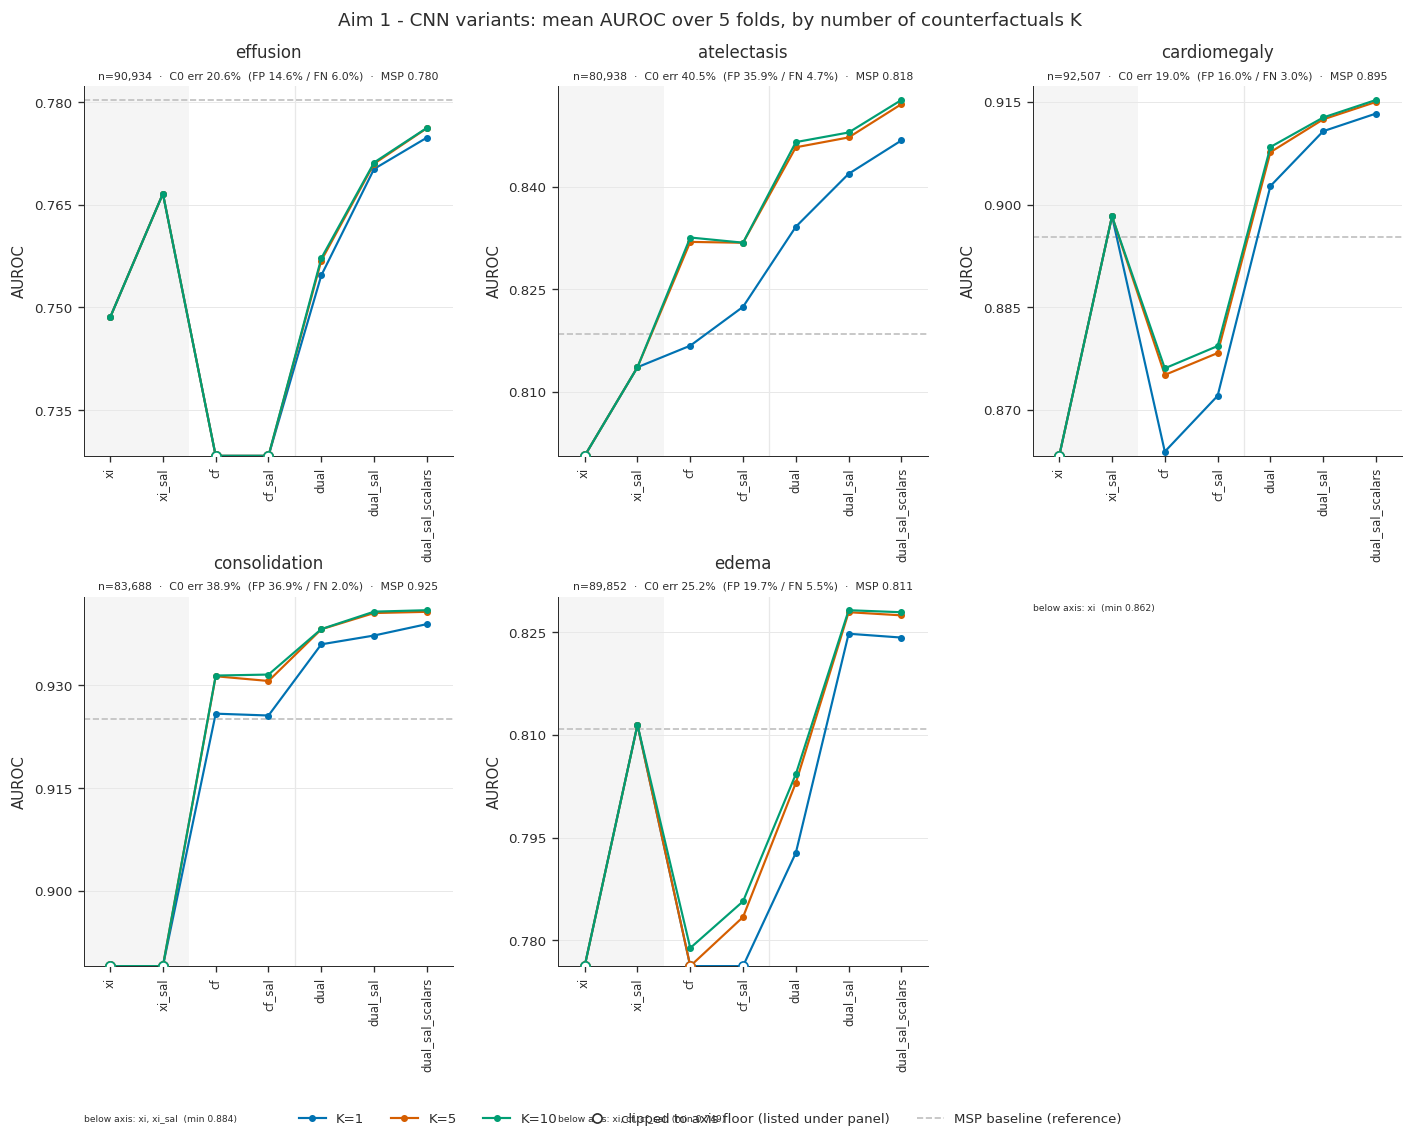

In [8]:
def cnn_ladder(diseases=DISEASES, ks=None, win=0.05, ncols=3, panel=(4, 4.6)):
    """Same figure for the image models. `xi` and `xi_sal` never see a counterfactual,
    so their K lines coincide by construction -- that is a check on the pipeline, not
    a finding. They are the shaded band."""
    ks, panels = ks or K_VALUES, []
    for d in diseases:
        # The C0 probability column is what MSP needs and it does not depend on K,
        # so one attribute frame (at CF) supplies it for every K series.
        att = load_attributes(d, CF)
        if att is None: continue
        series, ref, base = {}, None, None
        for k in ks:
            cnn = load_cnn(d, k)
            if cnn is None: continue
            cols = [f"cnn_{key}" for key in CNN_KEYS
                    if f"cnn_{key}" in cnn.columns and cnn[f"cnn_{key}"].notna().all()]
            if not cols: continue
            # MSP must be scored on the SAME rows as the CNN, so merge and take one frame.
            m = cnn.merge(att[["path", f"{d}_prob"]], on="path", how="inner")
            series[k] = {c.replace("cnn_", ""): per_fold_auc(m, c) for c in cols}
            if ref is None:
                ref, base = m, per_fold_auc(m, msp(m, d))
        if series:
            panels.append((d, ref, base, series))

    if not panels:
        print("no finished CNN models yet"); return
    rows = [key for key in CNN_KEYS if any(key in s[k] for _, _, _, s in panels for k in s)]

    fig, axes = _grid(len(panels), ncols, panel)
    for ax, (d, ref, base, series) in zip(axes, panels):
        # Shade the no-counterfactual models, NOT CNN_GROUPS[0] -- that group also
        # holds cf and cf_sal, which are counterfactual models.
        line_panel(ax, rows, series, CNN_GROUPS, auroc_ylim(series, base, win),
                   base=base, shade=CNN_NO_CF)
        _panel_title(ax, d, ref, base)
        ax.set_ylabel("AUROC")
    fig.legend(handles=k_legend(ks), loc="lower center", ncol=len(ks) + 2, frameon=False,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Aim 1 - CNN variants: mean AUROC over 5 folds, by number of "
                 "counterfactuals K", y=1.0, fontsize=11, color=INK)
    fig.tight_layout(rect=(0, 0.02, 1, 0.99))
    return fig

cnn_ladder();


# Aim 2 - is it better than the baseline?

Aim 1 showed which inputs carry correctness signal, and how that depends on K. This section
asks the only question that decides whether any of it is worth deploying: **does it beat
MSP?**

One attribute model and one CNN per disease, against the baseline. No config is singled out
by name anywhere - the winner is whatever the numbers choose, which on effusion happens to be
`B1` and elsewhere is usually `MCF1`.

**The search is over (config, K) jointly**, by mean fold AUROC. K is part of the method, so
fixing it at 1 and then reporting the gap would be reporting an arbitrarily handicapped
version of the method: on effusion the best attribute model at K=1 is +0.001 over MSP, while
the best over all K is +0.004. Every candidate is scored on the same rows and the same folds,
so the search is fair, and the chosen K is printed alongside the config in every label.

This section deliberately shows only the strongest case the method can make, because a method
that cannot beat the baseline at its best does not beat it. The full ladders across every
config and every K are in Aim 1.

Two views of the same comparison. The lollipops give the AUROC gap, signed and on one shared
scale. The risk-coverage curves give the deployment reading: reject the least-confident share,
and see what happens to the residual error rate.

## 2a. Best model vs MSP

Each disease gets two lines drawn from MSP: one for the best attribute model, one for the
best CNN, each the winner of a joint search over config and K. Length is the gain, blue and
green clear MSP and orange falls short, and the scale is shared across diseases so the
lengths are comparable. The absolute MSP level and the winning K are in the row labels.

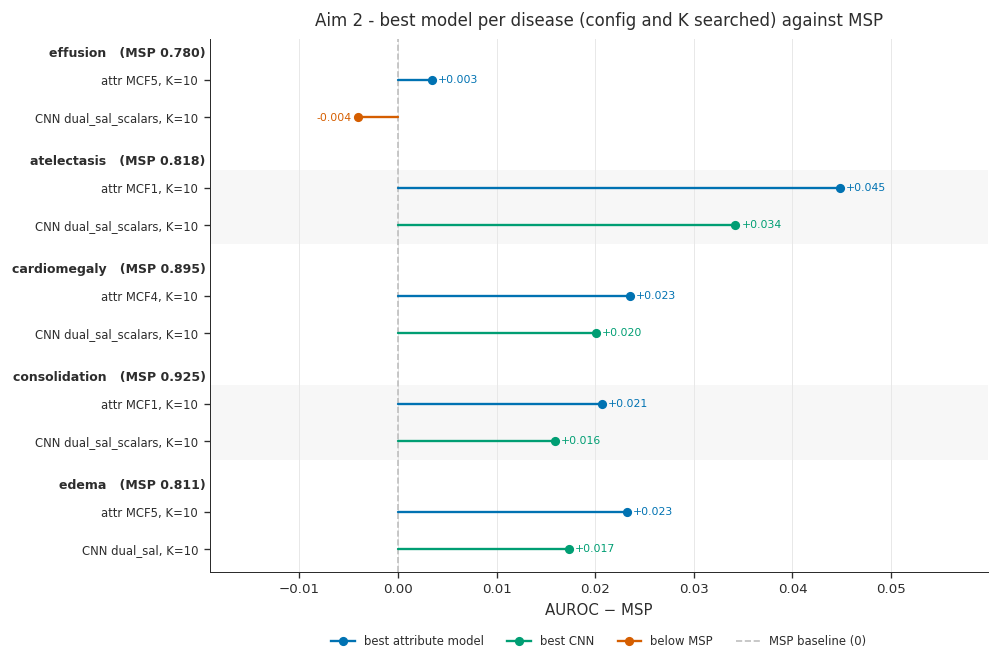

In [9]:
def best_attr(disease, model="MLP", ks=None):
    """Best (config, K) for the attribute models, by mean fold AUROC.

    Returns (config, K, score vector, frame, auroc). The score vector is returned
    rather than a column name because the winning K decides which frame the column
    lives in, and the caller needs the two together.

    K is searched, not fixed: it is a knob of the method, and reporting the gap at
    an arbitrary K understates what the method does.
    """
    best = None
    for k in (ks or K_VALUES):
        df = load_attributes(disease, k)
        if df is None: continue
        for c, col in config_cols(df, model).items():
            a = per_fold_auc(df, col)
            if best is None or a > best[-1]:
                best = (c, k, df[col], df, a)
    return best


def best_cnn(disease, ks=None):
    """Best (variant, K) for the image models, by mean fold AUROC.
    Returns (variant, K, frame, column, auroc)."""
    best = None
    for k in (ks or K_VALUES):
        cnn = load_cnn(disease, k)
        if cnn is None: continue
        for key in CNN_KEYS:
            col = f"cnn_{key}"
            if col not in cnn.columns or not cnn[col].notna().all():
                continue
            a = per_fold_auc(cnn, col)
            if best is None or a > best[-1]:
                best = (key, k, cnn, col, a)
    return best


BEST_LEGEND = [Line2D([],[],color=BLUE,lw=1.4,marker="o",ms=4.5,label="best attribute model"),
               Line2D([],[],color=TEAL,lw=1.4,marker="o",ms=4.5,label="best CNN"),
               Line2D([],[],color=VERM,lw=1.4,marker="o",ms=4.5,label="below MSP"),
               Line2D([],[],color=GREY,lw=1.0,ls="--",label="MSP baseline (0)")]

def best_vs_msp(diseases=DISEASES, model="MLP", ks=None, figsize=(8.4, 5.6),
                pad=0.006, gap=0.9):
    """One row per (disease, family): the AUROC gap of the best model over MSP.

    Deltas, not absolutes, because this is the comparison plot -- the length IS the
    answer to "is it better". The absolute MSP level is printed on each row label
    so nothing is lost.

    The CNN is scored on the rows it actually has, and MSP is recomputed on those
    same rows, so a CNN that finished on a subset is still compared like for like.

    Diseases are separated by a blank `gap` in y and named ONCE, in a heading above
    each pair, with the two rows labelled only by model. Repeating the disease on
    both rows and ruling a hairline between pairs -- the earlier design -- made the
    name the most repeated text in the figure while the pair still did not read as
    one block. White space groups more strongly than a rule.
    """
    blocks = []
    for d in diseases:
        ref = load_attributes(d, CF)
        if ref is None: continue
        rows = []

        a = best_attr(d, model, ks)
        if a:
            cfg, k, score, adf, auc = a
            base = per_fold_auc(adf, msp(adf, d))
            rows.append((auc - base, BLUE, f"attr {cfg}, K={k}", base))

        c = best_cnn(d, ks)
        if c:
            key, k, cnn, col, _ = c
            m = cnn.merge(ref[["path", f"{d}_prob"]], on="path", how="inner")
            cbase = per_fold_auc(m, msp(m, d))
            rows.append((per_fold_auc(m, col) - cbase, TEAL, f"CNN {key}, K={k}", cbase))

        if rows:
            blocks.append((d, rows))

    if not blocks:
        print("nothing to compare yet"); return

    # Lay the rows out with a gap between diseases, so y is no longer a plain range.
    placed, y = [], 0.0
    for d, rows in blocks:
        placed.append((d, y, [(y + j, *r) for j, r in enumerate(rows)]))
        y += len(rows) - 1 + gap + 1

    flat = [r for _, _, rs in placed for r in rs]
    vals = [v for _, v, _, _, _ in flat]
    # Extra room on each side for the printed value, which sits outside the dot;
    # without it a negative bar's label runs off the left edge.
    lo, hi = min(vals + [0.0]) - pad * 2.5, max(vals + [0.0]) + pad * 2.5

    fig, ax = plt.subplots(figsize=figsize)
    ax.axvline(0.0, color=GREY, ls="--", lw=1.0, zorder=1)

    # Shade alternate disease blocks. A band reads as "these rows belong together"
    # where a rule only says "something changes here".
    for i, (d, y0, rs) in enumerate(placed):
        if i % 2:
            ax.axhspan(y0 - 0.5, y0 + len(rs) - 0.5, color=INK, alpha=0.035,
                       lw=0, zorder=0)

    for yy, v, colr, _, _ in flat:
        c = colr if v >= 0 else VERM
        ax.plot([0.0, v], [yy, yy], color=c, lw=1.4, solid_capstyle="round", zorder=2)
        ax.plot(v, yy, "o", ms=4.5, color=c, zorder=3)
        ax.text(v + (0.0006 if v >= 0 else -0.0006), yy, f"{v:+.3f}", color=c,
                fontsize=6.5, va="center", ha="left" if v >= 0 else "right")

    # The disease name sits above its pair, in the axes' left margin, so the tick
    # labels carry only what differs between the two rows.
    for d, y0, rs in placed:
        ax.text(-0.005, y0 - 0.72, f"{d}   (MSP {rs[0][4]:.3f})",
                transform=ax.get_yaxis_transform(), ha="right", va="center",
                fontsize=7.5, color=INK, fontweight="bold")

    ax.set_xlim(lo, hi)
    ax.set_yticks([r[0] for r in flat])
    ax.set_yticklabels([r[3] for r in flat], fontsize=7)
    ax.set_ylim(max(r[0] for r in flat) + 0.6, -1.1)
    ax.set_xlabel("AUROC − MSP")
    ax.grid(axis="x", zorder=0); ax.set_axisbelow(True)
    # Legend below the axes: at 10 rows it otherwise lands on the bottom disease's bars.
    ax.legend(handles=BEST_LEGEND, loc="upper center", bbox_to_anchor=(0.5, -0.10),
              ncol=4, frameon=False, fontsize=7)
    ax.set_title("Aim 2 - best model per disease (config and K searched) against MSP",
                 color=INK, pad=8)
    fig.tight_layout()
    return fig

best_vs_msp();

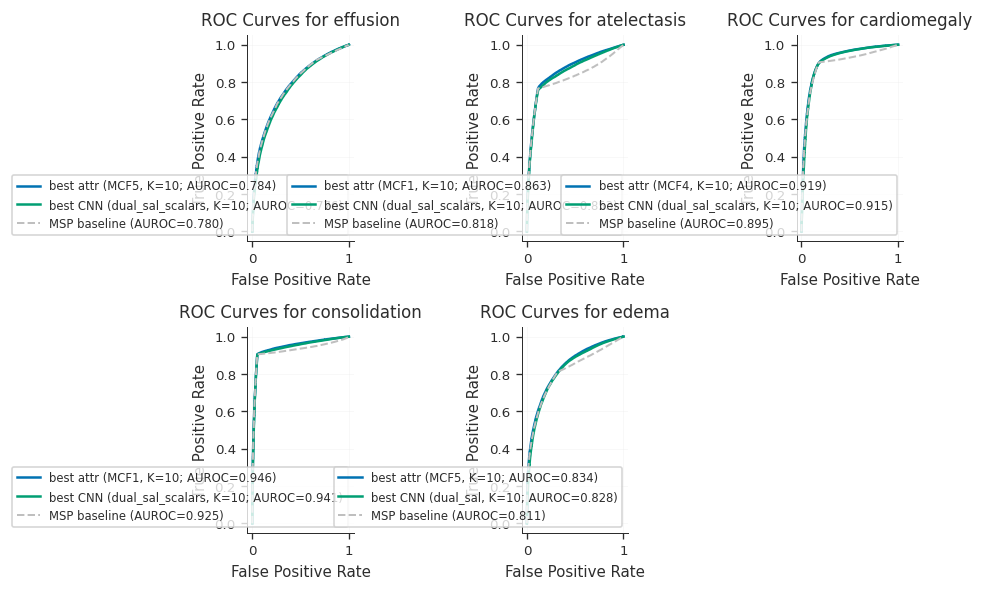

In [14]:
import math
import matplotlib.pyplot as plt

def plot_roc_curves(diseases=DISEASES, model="MLP", ks=None, cols=2, figsize=(10, 8)):
    """Plot ROC curves for the best attribute model and best CNN against MSP for each disease."""
    # Calculate required rows for the grid
    n_diseases = len(diseases)
    rows = math.ceil(n_diseases / cols)

    # Create grid of subplots
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # Loop through the grid
    for i, ax in enumerate(axes):
        # Hide any extra empty subplots if grid size > number of diseases
        if i >= n_diseases:
            ax.set_axis_off()
            continue
            
        d = diseases[i]
        ref = load_attributes(d, CF)
        if ref is None:
            ax.text(0.5, 0.5, f"{d}\nno attribute predictions yet",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color=MUTED)
            ax.set_axis_off()
            continue

        best_attr_model = best_attr(d, model, ks)
        best_cnn_model = best_cnn(d, ks)

        base_df = ref
        if best_attr_model:
            cfg, k, score, adf, auc = best_attr_model
            fpr_attr, tpr_attr, _ = roc_curve(adf["correct"], score)
            ax.plot(fpr_attr, tpr_attr, color=BLUE, lw=1.5,
                    label=f"best attr ({cfg}, K={k}; AUROC={auc:.3f})")
            base_df = adf

        if best_cnn_model:
            key, k, cnn_df, col, auc_cnn = best_cnn_model
            m = cnn_df.merge(ref[["path", f"{d}_prob"]], on="path", how="inner")
            if not m.empty:
                fpr_cnn, tpr_cnn, _ = roc_curve(m["correct"], m[col])
                ax.plot(fpr_cnn, tpr_cnn, color=TEAL, lw=1.5,
                        label=f"best CNN ({key}, K={k}; AUROC={auc_cnn:.3f})")
                base_df = m

        if base_df is not None:
            base_score = msp(base_df, d)
            fpr_msp, tpr_msp, _ = roc_curve(base_df["correct"], base_score)
            base_auc = per_fold_auc(base_df, base_score)
            ax.plot(fpr_msp, tpr_msp, color=GREY, linestyle="--", lw=1.2,
                    label=f"MSP baseline (AUROC={base_auc:.3f})")

        ax.set_title(f"ROC Curves for {d}")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(loc="lower right", fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

# Example usage:
plot_roc_curves(cols=3, figsize=(7, 5));

## 2b. Ensembling attributes and CNNs

The two families read different things - one the counterfactual *attributes*, the other the
*images* - so the question 2a leaves open is whether they are complementary: does combining
them rank C0's errors better than either alone?

Computed by `c2_ensemble.py`, not here; this cell only reads its `ensemble_summary.csv`.
That script takes the best attribute model and the best CNN for a disease, each by
cross-validated AUC, and combines them three ways:

| Combiner | What it does |
|---|---|
| `mean` | Average of the two probabilities. Assumes they are comparably calibrated. |
| `rank` | Average of within-fold percentile ranks. Calibration-free, so it asks whether the two *order* cases differently. |
| `lr` | Logistic regression on the two probabilities, fitted leave-one-fold-out. |

**The dashed line is the better of the two inputs, not MSP.** Both components already clear
MSP, so an ensemble that only beats the baseline has shown nothing; a bar has to clear the
dashed line to mean anything.

The deltas are thousandths of AUROC and nothing here is significance-tested, so read the table
descriptively: the `± std` on each row is the spread across the five folds, and a delta
smaller than that is not a result.

,K,attr,CNN,attr ↑,CNN ↑,best component,mean ↑,mean Δ,rank ↑,rank Δ,lr ↑,lr Δ
disease,,,,,,,,,,,,
effusion,10,MLP_MCF5,dual_sal_scalars,0.7838,0.7762,0.7838,0.7863,0.0026,0.7882,0.0044,0.7872,0.0034
atelectasis,10,MLP_MCF1,dual_sal_scalars,0.8632,0.8527,0.8632,0.8605,-0.0028,0.8617,-0.0015,0.8630,-0.0002
cardiomegaly,10,MLP_MCF4,dual_sal_scalars,0.9187,0.9153,0.9187,0.9193,0.0006,0.9206,0.0019,0.9192,0.0005
consolidation,10,MLP_MCF1,dual_sal_scalars,0.9457,0.9410,0.9457,0.9447,-0.0010,0.9456,-0.0001,0.9454,-0.0003
edema,10,MLP_MCF5,dual_sal,0.8341,0.8282,0.8341,0.8362,0.0021,0.8366,0.0025,0.8365,0.0023


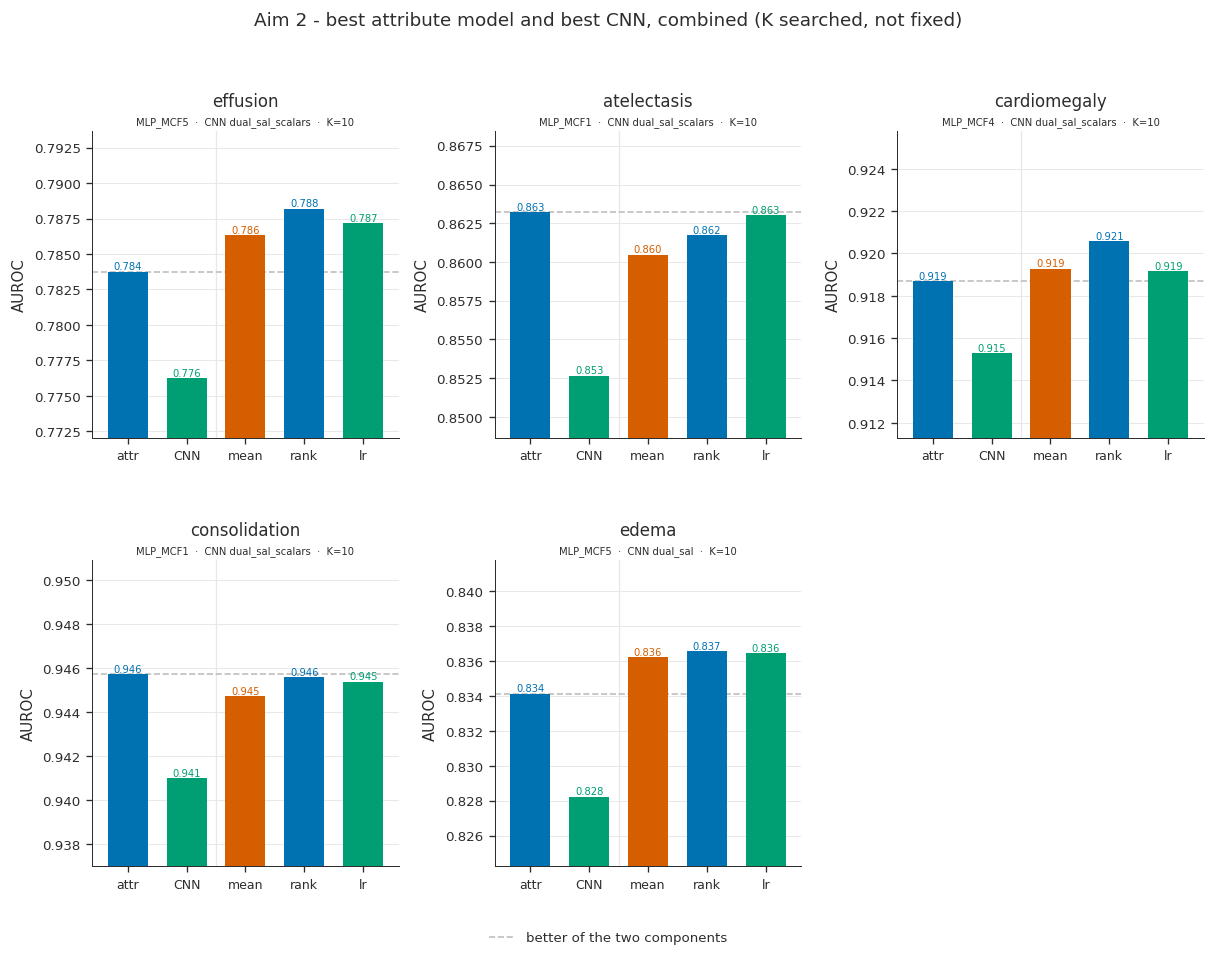

In [9]:
ENS_METHODS = ["mean", "rank", "lr"]
ENS_COLOR   = {"mean": VERM, "rank": BLUE, "lr": TEAL}


def load_ensemble(disease, k):
    """`ensemble_summary.csv` for one disease and K, or None if that run is absent.

    Written by c2_ensemble.py; nothing is fitted here.
    """
    p = os.path.join(C2, disease, SOURCE, f"cf_{k}", "ensemble", "ensemble_summary.csv")
    if not os.path.exists(p):
        return None
    df   = pd.read_csv(p)
    comp = df[df["kind"] == "component"].set_index("members")["auc_mean"]
    ens  = df[df["kind"] == "ensemble"].set_index("method")
    if comp.empty or ens.empty:
        return None
    # members is "<model>_prob"; only the attribute one carries an estimator prefix.
    attr = next((m for m in comp.index if m.split("_")[0] in ("MLP", "LR", "RF")), None)
    cnn  = next((m for m in comp.index if m != attr), None)
    if attr is None or cnn is None:
        return None
    return {"k": k, "attr": (attr[:-5], float(comp[attr])),
            "cnn": (cnn[:-5], float(comp[cnn])), "ens": ens}


def best_ensemble(disease, ks=None):
    """The K whose run has the strongest CNN -- K is searched, not pinned.

    The sweep is uneven: dual_sal_scalars, the best CNN variant, only finished at
    K=1, so a fixed K=10 silently swaps it for dual or xi_sal and then labels that
    "best CNN". On effusion that is 0.775 traded for 0.767, on cardiomegaly 0.913
    for 0.908 -- a worse model chosen for the sake of a larger K.

    Ranked by the CNN specifically, not by the better of the two: the attribute model
    wins on every disease, so ranking by the max would just pick the best attribute K
    and let the CNN follow, which is the behaviour this exists to avoid. The CNN is
    the side the uneven sweep penalises, so the CNN chooses the row.

    Chosen on what goes INTO the ensemble rather than on the ensemble's own score:
    picking by the ensemble would select for a combiner getting lucky on one split.
    """
    cands = [e for k in (ks or K_VALUES) if (e := load_ensemble(disease, k))]
    if not cands:
        return None
    return max(cands, key=lambda e: e["cnn"][1])


def ensemble_panel(ax, disease):
    """One disease: the two components and the three combiners, on an absolute axis.

    Absolute AUROC rather than a delta, because the question is where the ensembles
    sit RELATIVE TO THE BETTER COMPONENT -- which is a line on this axis, not a zero.
    Beating MSP is not the bar here: both components already do that.
    """
    e = best_ensemble(disease)
    if e is None:
        ax.text(0.5, 0.5, f"{disease}\nno ensemble run", transform=ax.transAxes,
                ha="center", va="center", fontsize=8, color=MUTED)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_box_aspect(1)
        return

    (acfg, aauc), (ckey, cauc) = e["attr"], e["cnn"]
    names = ["attr", "CNN"] + ENS_METHODS
    vals  = [aauc, cauc] + [float(e["ens"].loc[m, "auc_mean"])
                            if m in e["ens"].index else np.nan for m in ENS_METHODS]
    cols  = [BLUE, TEAL] + [ENS_COLOR[m] for m in ENS_METHODS]

    x = np.arange(len(names))
    ax.axhline(max(aauc, cauc), color=GREY, ls="--", lw=1.0, zorder=2)
    for xi, v, c in zip(x, vals, cols):
        if np.isnan(v):
            continue
        ax.bar(xi, v, width=0.68, color=c, zorder=3)
        ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=6.0,
                color=c, zorder=4)

    # Windowed y: the differences are thousandths, and a 0-1 axis flattens them.
    lo, hi = min(v for v in vals if v == v), max(v for v in vals if v == v)
    pad = max((hi - lo) * 0.35, 0.004)
    ax.set_ylim(lo - pad, hi + pad * 1.3)

    ax.axvline(1.5, color=HAIR, lw=0.8, zorder=0)      # components | ensembles
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=7.5)
    ax.set_xlim(-0.6, len(names) - 0.4)
    ax.set_ylabel("AUROC")
    ax.set_title(disease, color=INK, pad=15)
    ax.text(0.5, 1.012, f"{acfg}  ·  CNN {ckey}  ·  K={e['k']}", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=6.0, color=MUTED)
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
    ax.set_box_aspect(1)


fig, axes = _grid(len(DISEASES), 3, panel=(3.4, 3.9))
for ax, d in zip(axes, DISEASES):
    ensemble_panel(ax, d)
fig.legend(handles=[Line2D([], [], color=GREY, lw=1.0, ls="--",
                           label="better of the two components")],
           loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Aim 2 - best attribute model and best CNN, combined "
             "(K searched, not fixed)", y=1.0, fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0.02, 1, 0.99))

# The numbers behind the panels. `Δ` is against the better component; K varies by
# row because it is searched rather than pinned.
rows = []
for d in DISEASES:
    e = best_ensemble(d)
    if e is None:
        continue
    (acfg, aauc), (ckey, cauc) = e["attr"], e["cnn"]
    row = {"disease": d, "K": e["k"], "attr": acfg, "CNN": ckey,
           "attr ↑": round(aauc, 4), "CNN ↑": round(cauc, 4),
           "best component": round(max(aauc, cauc), 4)}
    for m in ENS_METHODS:
        if m in e["ens"].index:
            row[f"{m} ↑"] = round(float(e["ens"].loc[m, "auc_mean"]), 4)
            row[f"{m} Δ"] = round(float(e["ens"].loc[m, "delta_vs_best"]), 4)
    rows.append(row)

pd.DataFrame(rows).set_index("disease") if rows else "no ensemble runs yet"

## 2b. Risk-coverage

The deployment view: reject the least-confident share, and see what happens to the residual
error rate. Same winners as 2a - best attribute model and best CNN, each searched over config
and K - against MSP.

This answers *"is C2 useful?"* without conditioning the evaluation set on the C0 probability.
Selecting a confidence band by that probability strips MSP of its only feature and hands the
win to any richer config by construction.

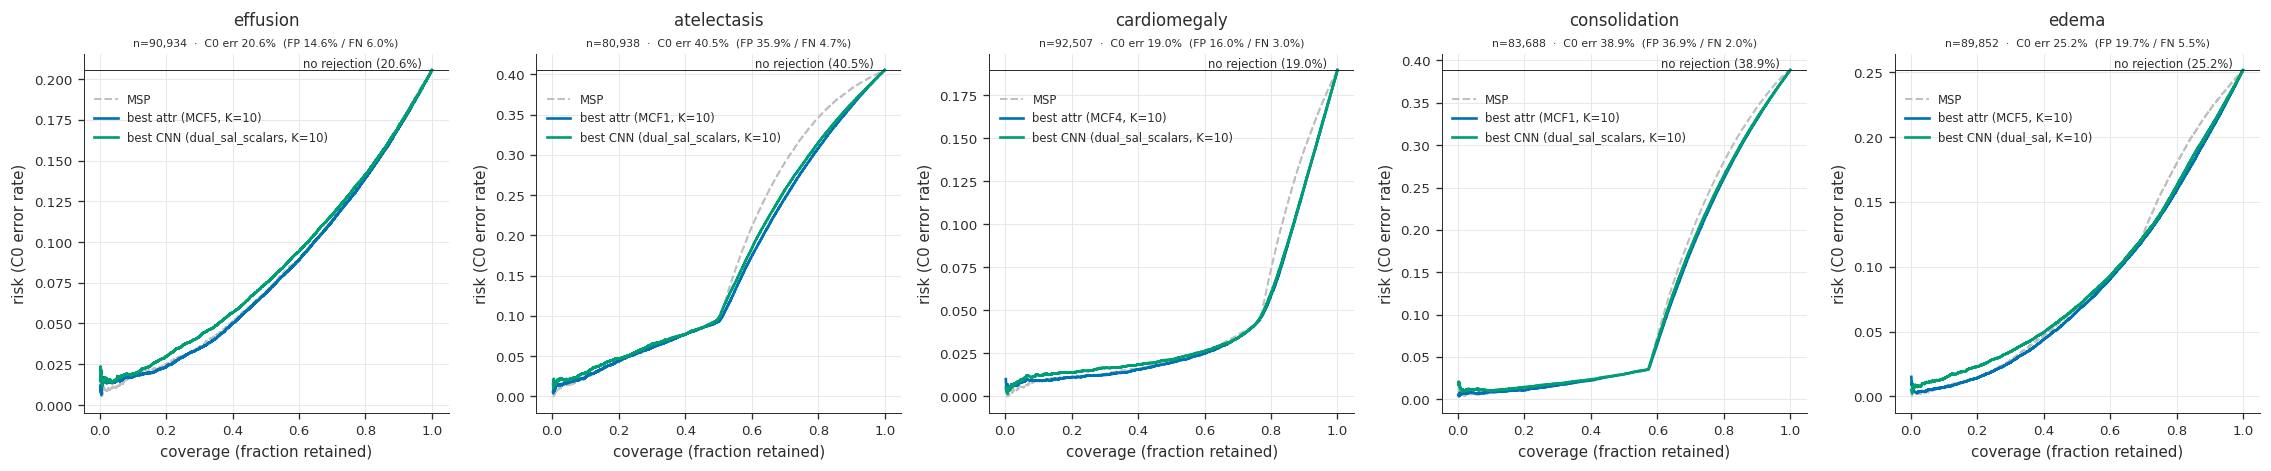

In [10]:
def risk_coverage_plot(disease, model="MLP", ks=None, ax=None):
    """MSP against the best model in each family -- no config is singled out by name.
    The winner is the joint (config, K) argmax of mean fold AUROC, the same one 2a
    draws, so the two figures always describe the same models."""
    ref = load_attributes(disease, CF)
    if ref is None:
        print(f"{disease}: no attribute predictions yet"); return
    ax = ax or plt.subplots(figsize=(5.2, 4))[1]

    cov, risk = risk_coverage(ref["correct"], msp(ref, disease))
    ax.plot(cov, risk, color=GREY, ls="--", lw=1.2, label="MSP")

    a = best_attr(disease, model, ks)
    if a:
        cfg, k, score, adf, _ = a
        cov, risk = risk_coverage(adf["correct"], score)
        ax.plot(cov, risk, color=BLUE, lw=1.6, label=f"best attr ({cfg}, K={k})")

    c = best_cnn(disease, ks)
    if c:
        key, k, cnn, col, _ = c
        m = ref.merge(cnn[["path", col]], on="path", how="inner")
        cov, risk = risk_coverage(m["correct"], m[col])
        ax.plot(cov, risk, color=TEAL, lw=1.6, label=f"best CNN ({key}, K={k})")

    base = 1 - ref["correct"].mean()
    ax.axhline(base, color=MUTED, lw=0.6)
    ax.text(0.98, base, f"no rejection ({base:.1%}) ", fontsize=7, color=MUTED,
            va="bottom", ha="right")          # right-aligned: the legend owns the top-left
    ax.set_xlabel("coverage (fraction retained)"); ax.set_ylabel("risk (C0 error rate)")
    titled(ax, disease, ref)
    ax.grid(zorder=0); ax.set_axisbelow(True)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.92), fontsize=7)
    return ax

fig, axes = plt.subplots(1, len(DISEASES), figsize=(19, 4.0))
for ax, d in zip(axes, DISEASES):
    risk_coverage_plot(d, ax=ax)
fig.tight_layout()

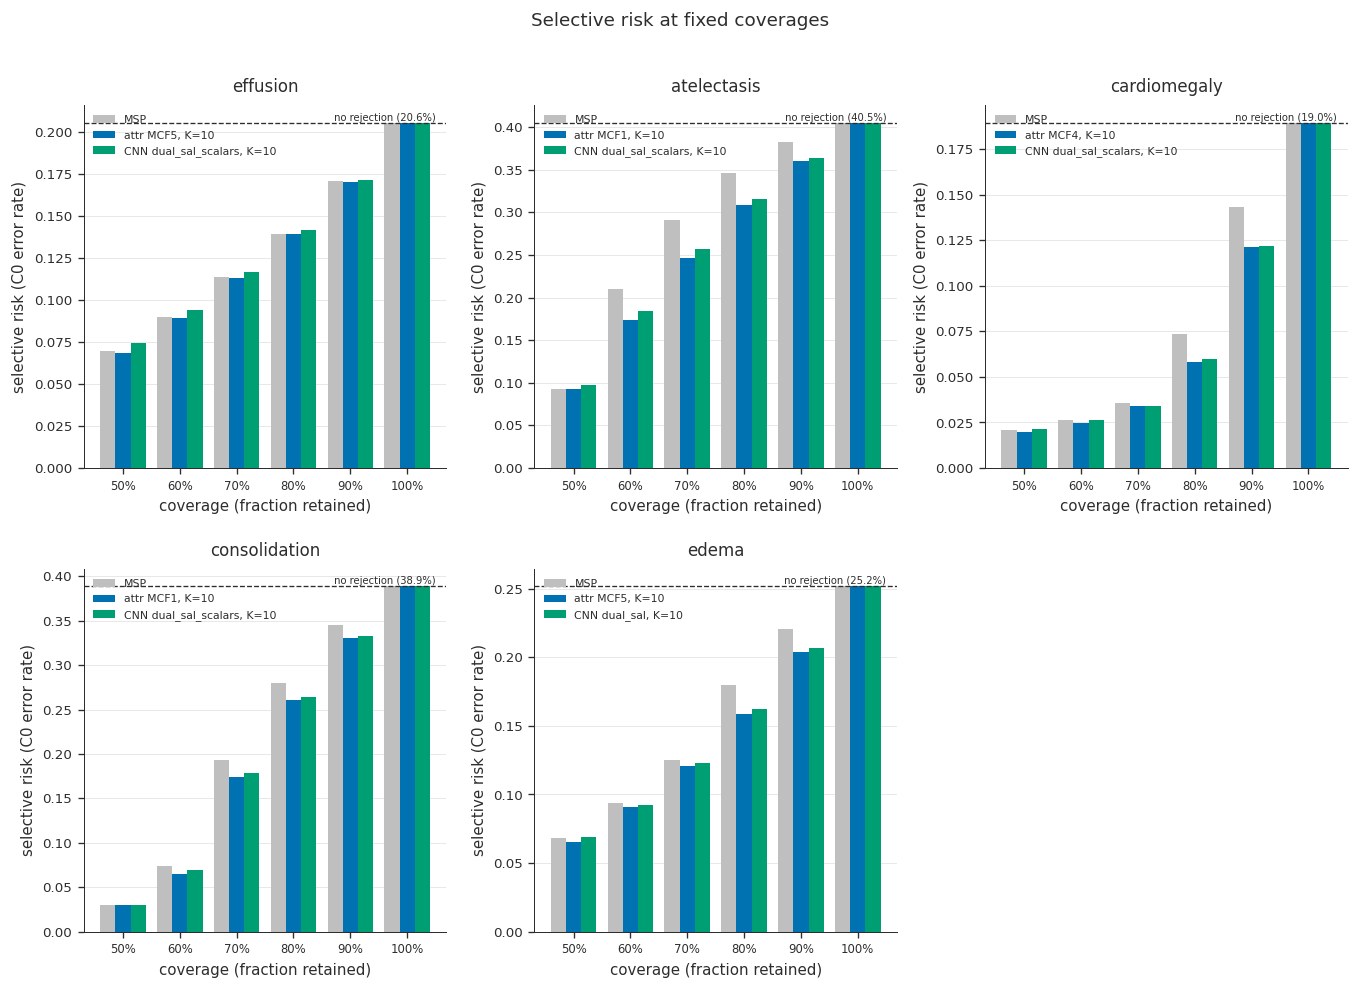

In [40]:
def selective_risk_panel(ax, disease, coverages=COVERAGES):
    ref = load_attributes(disease, CF)
    if ref is None:
        return

    lines = {"MSP": risk_at(ref["correct"], msp(ref, disease), coverages)}
    labels = {"MSP": "MSP"}

    a = best_attr(disease, "MLP", K_VALUES)
    if a:
        cfg, k, score, adf, _ = a
        lines["attr"] = risk_at(adf["correct"], score, coverages)
        labels["attr"] = f"attr {cfg}, K={k}"

    c = best_cnn(disease, K_VALUES)
    if c:
        key, k, cnn, col, _ = c
        m = ref.merge(cnn[["path", col]], on="path", how="inner")
        lines["CNN"] = risk_at(m["correct"], m[col], coverages)
        labels["CNN"] = f"CNN {key}, K={k}"

    x = np.arange(len(coverages))
    w = 0.8 / len(lines)
    for i, (name, y) in enumerate(lines.items()):
        off = (i - (len(lines) - 1) / 2) * w
        ax.bar(x + off, y, width=w, color=SC_COLOR[name], zorder=2, label=labels[name])

    base = 1 - ref["correct"].mean()
    ax.axhline(base, color=MUTED, lw=0.8, ls="--", zorder=3)
    ax.text(len(coverages) - 0.5, base, f" no rejection ({base:.1%})", fontsize=6,
            color=MUTED, va="bottom", ha="right")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{c:.0%}" for c in coverages], fontsize=7)
    ax.set_xlabel("coverage (fraction retained)")
    ax.set_ylabel("selective risk (C0 error rate)")
    ax.set_title(disease, color=INK, pad=8)
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=6.5, loc="upper left")
    ax.set_box_aspect(1)
    
fig, axes = _grid(len(DISEASES), 3, panel=(3.8, 4.2))
for ax, d in zip(axes, DISEASES):
    selective_risk_panel(ax, d)
fig.suptitle("Selective risk at fixed coverages", y=1.0, fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0.02, 1, 0.99))


# 3 - Stratified Performance

In [ ]:
# Get BEST Models (Best Attribute and Best CNN) for each disease
best_models = {}
for d in DISEASES:
    best_attr_model = best_attr(d)
    best_cnn_model = best_cnn(d)
    best_models[d] = {
        "best_attr": {
            "config": best_attr_model[0],
            "K": best_attr_model[1],
            "AUROC": best_attr_model[4]
        },
        "best_cnn": {
            "variant": best_cnn_model[0],
            "K": best_cnn_model[1],
            "AUROC": best_cnn_model[4]
        }
    }
    print(f"Disease: {d}")
    print(f"  Best Attribute Model: Config={best_attr_model[0]}, K={best_attr_model[1]}, AUROC={best_attr_model[4]:.4f}")
    print(f"  Best CNN Model: Variant={best_cnn_model[0]}, K={best_cnn_model[1]}, AUROC={best_cnn_model[4]:.4f}")


Disease: effusion
  Best Attribute Model: Config=MCF5, K=10, AUROC=0.7838
  Best CNN Model: Variant=dual_sal_scalars, K=10, AUROC=0.7762
Disease: atelectasis
  Best Attribute Model: Config=MCF1, K=10, AUROC=0.8632
  Best CNN Model: Variant=dual_sal_scalars, K=10, AUROC=0.8527
Disease: cardiomegaly
  Best Attribute Model: Config=MCF4, K=10, AUROC=0.9187
  Best CNN Model: Variant=dual_sal_scalars, K=10, AUROC=0.9153
Disease: consolidation
  Best Attribute Model: Config=MCF1, K=10, AUROC=0.9457
  Best CNN Model: Variant=dual_sal_scalars, K=10, AUROC=0.9410
Disease: edema
  Best Attribute Model: Config=MCF5, K=10, AUROC=0.8341
  Best CNN Model: Variant=dual_sal, K=10, AUROC=0.8282


In [15]:
N_BANDS = 5

def confidence_bands(conf, n_bands=N_BANDS):
    band, edges = pd.qcut(conf, n_bands, labels=False, retbins=True, duplicates="drop")
    return band, edges

def band_auc(correct, score, band):
    """AUROC per band. NaN where a band has only one class present (small-n edge case,
    same guard as safe_auc in c0_final_predictions.py) rather than raising."""
    out = []
    for b in range(band.max() + 1):
        m = band == b
        y = np.asarray(correct)[m]
        if len(np.unique(y)) < 2:
            out.append(np.nan)
        else:
            out.append(float(roc_auc_score(y, np.asarray(score)[m])))
    return out

def band_n(band):
    return [int((band == b).sum()) for b in range(band.max() + 1)]



## 3a. Per-disease panels

 One panel per disease, same grid convention as Aim 1 / 2a. Four lines: MSP (grey dashed,
 expected to sag toward the edges by construction -- see above), best attribute model, best
 CNN, best ensemble. X axis is band 1 (least confident) to band 5 (most confident); band
 edges and per-band n are printed under each panel so the reader can see where the bins fall
 and how thin the tails are.

/tmp/ipykernel_2294913/1044008156.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, arr, "-o", ms=4, lw=1.0 if name == "MSP" else 1.4,
/tmp/ipykernel_2294913/1044008156.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, arr, "-o", ms=4, lw=1.0 if name == "MSP" else 1.4,
/tmp/ipykernel_2294913/1044008156.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, arr, "-o", ms=4, lw=1.0 if name == "MSP" else 1.4,
/tmp/ipykernel_2294913/1044008156.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword

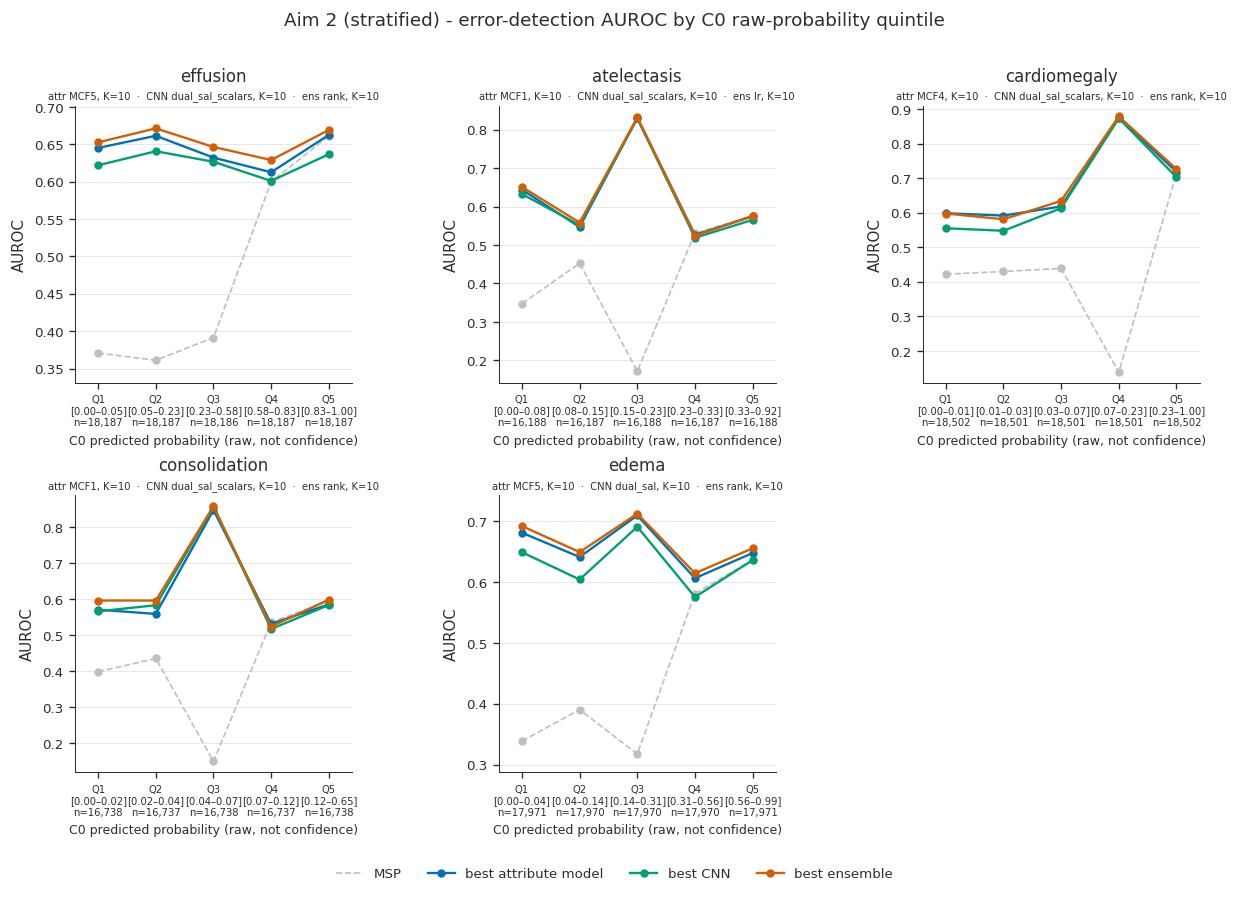

In [20]:
N_BANDS = 5
STRAT_COLOR = {"MSP": GREY, "attr": BLUE, "cnn": TEAL, "ens": VERM}

# Divide C0's probabilities for that disease into equal count bins
def prob_bands(df, disease, n_bands=N_BANDS):
    """Equal-count bin index + edges, from df[f'{disease}_prob']."""
    return pd.qcut(df[f"{disease}_prob"], n_bands, labels=False, retbins=True, duplicates="drop")

# Calculate AUROC per band and number of samples per band
def band_stats(correct, score, band, n_bands):
    """Per-band (AUROC, n). AUROC is NaN where a band has only one class."""
    aucs, ns = [], []
    for b in range(n_bands):
        y, s = np.asarray(correct)[band == b], np.asarray(score)[band == b]
        aucs.append(float(roc_auc_score(y, s)) if len(np.unique(y)) > 1 else np.nan)
        ns.append(len(y))
    return aucs, ns

# Use both functions defined above to output the list of results
def scored_line(df, disease, score_col, n_bands=N_BANDS):
    """Bin df by its OWN prob column, then score AUROC per band. One call handles
    MSP, attr, CNN and ensemble alike -- each frame supplies its own prob + score."""
    band, edges = prob_bands(df, disease, n_bands)
    aucs, ns = band_stats(df["correct"], df[score_col], band, n_bands)
    return aucs, ns, edges


# %%
def stratified_panel(ax, disease, model="MLP", ks=None, n_bands=N_BANDS):
    ref = load_attributes(disease, CF)
    if ref is None:
        ax.text(0.5, 0.5, f"{disease}\nno predictions yet", transform=ax.transAxes,
                ha="center", va="center", fontsize=8, color=MUTED)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_box_aspect(1)
        return

    lines, labels = {}, {}
    lines["MSP"], n, edges = scored_line(
        ref.assign(**{f"{disease}_prob_msp": ref[f"{disease}_prob"]}), disease,
        f"{disease}_prob", n_bands)

    a = best_attr(disease, model, ks)
    if a:
        cfg, k, score, adf, _ = a
        lines["attr"], _, _ = scored_line(adf.assign(_s=score), disease, "_s", n_bands)
        labels["attr"] = f"attr {cfg}, K={k}"

    c = best_cnn(disease, ks)
    if c:
        key, k, cnn, col, _ = c
        m = cnn.merge(ref[["path", f"{disease}_prob"]], on="path", how="inner")
        lines["cnn"], _, _ = scored_line(m, disease, col, n_bands)
        labels["cnn"] = f"CNN {key}, K={k}"

    e = best_ensemble(disease, ks)
    if e:
        p = os.path.join(C2, disease, SOURCE, f"cf_{e['k']}", "ensemble", "oof_predictions.csv")
        if os.path.exists(p):
            best_method = e["ens"]["auc_mean"].idxmax()
            col = f"ens_{best_method}"
            oof = pd.read_csv(p)
            if col in oof.columns:
                m = oof.merge(ref[["path", f"{disease}_prob"]], on="path", how="inner")
                lines["ens"], _, _ = scored_line(m, disease, col, n_bands)
                labels["ens"] = f"ens {best_method}, K={e['k']}"

    vals = [v for arr in lines.values() for v in arr if np.isfinite(v)]
    lo, hi = (min(vals) - 0.03, max(vals) + 0.03) if vals else (0.4, 1.0)
    ax.set_ylim(lo, hi)

    x = np.arange(n_bands)
    for name, arr in lines.items():
        ax.plot(x, arr, "-o", ms=4, lw=1.0 if name == "MSP" else 1.4,
                ls="--" if name == "MSP" else "-", color=STRAT_COLOR[name],
                zorder=2 if name == "MSP" else 3, label=name)

    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{i+1}\n[{edges[i]:.2f}\u2013{edges[i+1]:.2f}]\nn={n[i]:,}"
                        for i in x], fontsize=6)
    ax.set_xlim(-0.4, n_bands - 0.6)
    ax.set_xlabel("C0 predicted probability (raw, not confidence)", fontsize=7.5)
    ax.set_ylabel("AUROC")
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
    ax.set_box_aspect(1)
    ax.set_title(disease, color=INK, pad=15)
    ax.text(0.5, 1.015, "  \u00b7  ".join(labels.values()), transform=ax.transAxes,
            ha="center", va="bottom", fontsize=6.0, color=MUTED)


STRAT_LEGEND = [
    Line2D([], [], color=GREY, lw=1.0, ls="--", label="MSP"),
    Line2D([], [], color=BLUE, lw=1.4, marker="o", ms=4, label="best attribute model"),
    Line2D([], [], color=TEAL, lw=1.4, marker="o", ms=4, label="best CNN"),
    Line2D([], [], color=VERM, lw=1.4, marker="o", ms=4, label="best ensemble"),
]

fig, axes = _grid(len(DISEASES), 3, panel=(3.6, 3.6))
for ax, d in zip(axes, DISEASES):
    stratified_panel(ax, d)
fig.legend(handles=STRAT_LEGEND, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Aim 2 (stratified) - error-detection AUROC by C0 raw-probability quintile",
             y=1.0, fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0.03, 1, 0.99))


In [34]:
# Summary Table

def stratified_summary(diseases=DISEASES, model="MLP", ks=None, n_bands=N_BANDS):
    rows = []
    for d in diseases:
        a = best_attr(d, model, ks)
        if a is None:
            continue
        cfg, k, score, adf, _ = a
        msp_auc, _, edges = scored_line(adf, d, f"{d}_prob", n_bands)
        best_auc, _, _ = scored_line(adf.assign(_s=score), d, "_s", n_bands)
        thresh = c0_threshold(d)
        # which quintile the Youden cutpoint falls into, so a gain column can be read against where C0's actual decision boundary sits
        q = int(np.searchsorted(edges[1:-1], thresh)) + 1
        row = {"disease": d, "best config": f"{cfg} (K={k})",
               "Youden thresh": round(thresh, 4), "Youden in": f"Q{q}"}
        for i in range(n_bands):
            g = best_auc[i] - msp_auc[i]
            row[f"Q{i+1} gain"] = round(g, 4) if np.isfinite(g) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("disease")
 
stratified_summary()
 

,best config,Youden thresh,Youden in,Q1 gain,Q2 gain,Q3 gain,Q4 gain,Q5 gain
disease,,,,,,,,
effusion,MCF5 (K=10),0.3932,Q3,0.2743,0.3002,0.2406,0.0128,0.0016
atelectasis,MCF1 (K=10),0.1886,Q3,0.2960,0.0942,0.6586,-0.0041,-0.0013
cardiomegaly,MCF4 (K=10),0.1598,Q4,0.1764,0.1618,0.1793,0.7374,0.0044
consolidation,MCF1 (K=10),0.0671,Q3,0.1725,0.1235,0.6981,-0.0043,-0.0092
edema,MCF5 (K=10),0.2849,Q3,0.3428,0.2512,0.3925,0.0254,0.0109


## 2c. Summary table

Three metric families, all computed on the same pooled out-of-fold rows.

| Column | Meaning |
|---|---|
| `n samples` | C2 rows, pooled over the 5 folds. Every sample is scored exactly once, out-of-fold. |
| `C0 error rate` | Share of those rows where C0 was wrong at its operating threshold. This is what C2 is trying to predict, and it is the risk you carry if you reject nothing. |
| `AUROC MSP / best` | Mean AUROC over the 5 folds, **higher is better**. `MSP` is the untrained baseline; `best` is whichever (config, K) pair scored highest on that disease. |
| `AUROC gain vs MSP` | `best` minus `MSP` - what the whole attribute ladder buys over raw confidence. |
| `E-AURC MSP / best` | Excess area under the risk-coverage curve, **lower is better**. Average the risk over all coverages, then subtract what a perfect ranking would score. The subtraction strips out the base error rate, which spans 19-40% here and would otherwise make the diseases incomparable. Read it as "how far from a perfect error-detector, in average residual error". |
| `errors found @20%` | Send the 20% least-confident cases for review; this is the share of C0's **actual errors** that lands in that pile. **Random selection would find 20%**, so anything above that is the real triage value. Higher is better. |

The AUROC and `errors found` columns point up; `E-AURC` points down. The arrows in the header
say which.

In [11]:
def summary(diseases=DISEASES, model="MLP", ks=None, budget=0.20):
    """Same winner as 2a and 2b: the joint (config, K) argmax of mean fold AUROC."""
    rows = []
    for d in diseases:
        a = best_attr(d, model, ks)
        if a is None: continue
        cfg, k, score, df, auc = a
        m    = msp(df, d)
        base = per_fold_auc(df, m)
        rows.append({
            "disease": d,
            "n samples": len(df),
            "C0 error rate": f"{1 - df['correct'].mean():.1%}",
            "AUROC MSP ↑": round(base, 4),
            "best config": f"{cfg} (K={k})",
            "AUROC best ↑": round(auc, 4),
            "AUROC gain vs MSP": round(auc - base, 4),
            "E-AURC MSP ↓": round(e_aurc(df["correct"], m), 4),
            "E-AURC best ↓": round(e_aurc(df["correct"], score), 4),
            f"errors found @{budget:.0%} MSP ↑":
                f"{errors_caught(df['correct'], m, budget):.1%}",
            f"errors found @{budget:.0%} best ↑":
                f"{errors_caught(df['correct'], score, budget):.1%}",
        })
    return pd.DataFrame(rows).set_index("disease")

pd.set_option("display.width", 200, "display.max_columns", 50)
summary()

,n samples,C0 error rate,AUROC MSP ↑,best config,AUROC best ↑,AUROC gain vs MSP,E-AURC MSP ↓,E-AURC best ↓,errors found @20% MSP ↑,errors found @20% best ↑
disease,,,,,,,,,,
effusion,90934,20.6%,0.7803,MCF5 (K=10),0.7838,0.0034,0.0590,0.0584,45.8%,45.8%
atelectasis,80938,40.5%,0.8185,MCF1 (K=10),0.8632,0.0448,0.0779,0.0634,31.7%,39.2%
cardiomegaly,92507,19.0%,0.8952,MCF4 (K=10),0.9187,0.0235,0.0247,0.0207,68.9%,75.3%
consolidation,83688,38.9%,0.9250,MCF1 (K=10),0.9457,0.0207,0.0293,0.0233,42.3%,46.3%
edema,89852,25.2%,0.8109,MCF5 (K=10),0.8341,0.0233,0.0562,0.0508,43.0%,49.6%
